# Libs

In [ ]:
import numpy as np, json, time, sys

from scipy.spatial import cKDTree

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Blind search

## Simulator




### What the parameters do
- `dscales`, `weights`: the step-length mixture. `p(l) = sum_i w_i/d_i * exp(-l/d_i)`.
  For a biexponential pass `dscales=[d2, d1]`, `weights=[1-w_long, w_long]`,
  where `d2` is the **short/intensive** scale (search near the target you seek)
  and `d1` is the **long/relocating** scale. Weights are normalised internally.
- `W`: number of independent walkers (statistics). SEM scales as `1/sqrt(W)`.
- `h`: **numerical** integration substep. This is *not* physics — it is only
  how finely the straight flight is sampled for contact. It must be small
  enough to resolve the target: see the convergence check below.
- `max_path`: walkers exceeding this are censored (reported as `cens`). Keep
  `cens ~ 0`; if it is not, raise `max_path`.

### Approximations inside (worth knowing)
1. **Contact is sampled, not exact.** The code tests `distance <= r` at
   substep endpoints, so a flight can in principle clip a disk between
   samples. This is converged for `h <= 0.4` at `r = 0.5` (checked below);
   at `h = 1.0` it is badly wrong.
2. **Capture overshoots by up to `h`.** The path is credited the full substep
   in which contact is detected, rather than stopping exactly on the disk
   surface. This biases `T` upward by `O(h/2)` ~ 0.2, i.e. ~0.02% of `T`.
3. **Flight lengths are effectively quantised** to multiples of `h` (a new
   flight starts when `remaining <= 0`). Irrelevant when `d_i >> h`.
4. The target at distance `tau` is **live** (not depleted). Depletion is
   modelled purely through `tau`.

In [ ]:
def run_flight(L, Nt, r, tau, dscales, weights, W, seed, h=0.25, max_path=40000):
    """Blind biexponential searcher. Returns (mean_T, SEM, censored_fraction).
 
    T is the path length from the start (distance `tau` from a random target)
    to the first contact with any target.
    """
    rng = np.random.default_rng(seed)
 
    # --- environment: fixed uniform targets, periodic box ---
    targets = rng.uniform(0, L, size=(Nt, 2))
    tree = cKDTree(targets, boxsize=L)          # boxsize -> periodic queries
 
    # --- initial condition: each walker at distance tau from a random target,
    #     in a uniformly random direction, with a random heading ---
    ti = rng.integers(0, Nt, size=W)
    a0 = rng.uniform(0, 2 * np.pi, size=W)
    pos = (targets[ti] + tau * np.column_stack([np.cos(a0), np.sin(a0)])) % L
 
    head = np.zeros((W, 2))     # current flight direction (unit vector)
    remaining = np.zeros(W)     # path length left in the current flight
    path = np.zeros(W)          # accumulated path length = time
    done = np.zeros(W, bool)
 
    dscales = np.asarray(dscales, float)
    cw = np.cumsum(np.asarray(weights, float))
    cw /= cw[-1]                # normalised cumulative weights -> mode sampling
 
    def new_flights(mask):
        """Draw a fresh direction and an exponential length for masked walkers."""
        n = int(mask.sum())
        if n == 0:
            return
        mode = np.searchsorted(cw, rng.random(n))        # pick which exponential
        Ls = -dscales[mode] * np.log(rng.random(n))      # inverse-CDF exponential
        ang = rng.uniform(0, 2 * np.pi, n)               # fresh random direction
        head[mask] = np.column_stack([np.cos(ang), np.sin(ang)])
        remaining[mask] = Ls
 
    new_flights(~done)
 
    for _ in range(int(max_path / h)):
        act = ~done
        if not act.any():
            break
        new_flights(act & (remaining <= 0))   # start a new flight where needed
 
        pos[act] = (pos[act] + h * head[act]) % L   # advance one substep
        remaining[act] -= h
        path[act] += h
 
        d_near, _ = tree.query(pos[act], k=1)       # distance to nearest centre
        hit = d_near <= r                           # CONTACT -> acquired
        if hit.any():
            done[np.where(act)[0][hit]] = True
 
    p = path[done]
    return p.mean(), p.std() / np.sqrt(max(len(p), 1)), 1 - done.mean()

In [ ]:
tau = 2; d1 = 1000; d2 = 2; wl = 0.3; 
seed = 7; h = 0.25
L, Nt, r = 50, 100, 0.5          # box side, number of targets, acquisition radius


W = 8000

m, s, _ = run_flight(L, Nt, r, tau, [d2, d1], [1 - wl, wl],
                                 W=W, seed=seed, h=h)
m

np.float64(22.53778125)

## Grid search

In [ ]:
def optimize_blind(tau, d2_list=None, w_list=None, d1=1000.0,
                   W=1200, h=0.2, seed=7, verbose=False):
    """2D scan over (d2, w_long) at fixed d1. Returns (best_dict, table).
 
    table[i, j] = mean MFPT for d2_list[i], w_list[j].
    """
    if d2_list is None:
        d2_list = [0.5 * tau, 1.0 * tau, 2.0 * tau, 4.0 * tau]
    if w_list is None:
        w_list = [0.0, 0.02, 0.05, 0.1, 0.2, 0.3, 0.6, 1.0]
 
    table = np.full((len(d2_list), len(w_list)), np.nan)
    for i, d2 in enumerate(d2_list):
        for j, wl in enumerate(w_list):
            m, s, _ = run_flight(L, Nt, r, tau, [d2, d1], [1 - wl, wl],
                                 W=W, seed=seed, h=h)
            table[i, j] = m
    i, j = np.unravel_index(np.nanargmin(table), table.shape)
    best = {"tau": tau, "d2": d2_list[i], "w_long": w_list[j], "d1": d1,
            "T": table[i, j]}
    if verbose:
        print(f"tau = {tau}:  best d2 = {best['d2']:.2f}, "
              f"w_long = {best['w_long']:.2f},  T = {best['T']:.1f}")
    return best, table

In [ ]:
L, Nt, r = 50, 100, 0.5          # box side, number of targets, acquisition radius
rho = Nt / L**2                  # 1e-3
MFP = 1 / (2 * r * rho)          # mean free path ceiling  = 1000
B_CELL = 1 / np.sqrt(np.pi * rho)  # cell radius            = 17.8
A = 2 / (np.pi * rho)            # log-law prefactor 2/(pi rho) = 637 (visual walker)


best, table = optimize_blind(tau=2.0, W=8000)

tau = 2.0:  best d2 = 2.00, w_long = 0.30,  T = 22.1


## Scaling of MPFT vs tau

In [ ]:
L, Nt, r = 50, 100, 0.5          # box side, number of targets, acquisition radius
rho = Nt / L**2                  # 1e-3
MFP = 1 / (2 * r * rho)          # mean free path ceiling  = 1000
B_CELL = 1 / np.sqrt(np.pi * rho)  # cell radius            = 17.8
A = 2 / (np.pi * rho)   


taus = np.arange(1, 30)
mfpt = np.zeros(*taus.shape)
for idxt, tau in enumerate(taus):
    best, table = optimize_blind(tau=tau, W=800)
    mfpt[idxt] = best['T']

tau = 1:  best d2 = 0.50, w_long = 0.05,  T = 17.0
tau = 2:  best d2 = 1.00, w_long = 0.30,  T = 21.2
tau = 3:  best d2 = 12.00, w_long = 0.60,  T = 22.1
tau = 4:  best d2 = 4.00, w_long = 0.60,  T = 23.3
tau = 5:  best d2 = 5.00, w_long = 0.05,  T = 23.5
tau = 6:  best d2 = 12.00, w_long = 0.30,  T = 22.7
tau = 7:  best d2 = 3.50, w_long = 0.30,  T = 22.8
tau = 8:  best d2 = 8.00, w_long = 0.30,  T = 22.6
tau = 9:  best d2 = 9.00, w_long = 0.05,  T = 22.9
tau = 10:  best d2 = 20.00, w_long = 0.10,  T = 23.4
tau = 11:  best d2 = 11.00, w_long = 0.30,  T = 22.3
tau = 12:  best d2 = 24.00, w_long = 0.20,  T = 22.4
tau = 13:  best d2 = 52.00, w_long = 0.20,  T = 23.3
tau = 14:  best d2 = 56.00, w_long = 0.30,  T = 22.3
tau = 15:  best d2 = 60.00, w_long = 0.00,  T = 21.7
tau = 16:  best d2 = 64.00, w_long = 0.02,  T = 22.1
tau = 17:  best d2 = 34.00, w_long = 0.30,  T = 23.3
tau = 18:  best d2 = 18.00, w_long = 0.20,  T = 22.0
tau = 19:  best d2 = 76.00, w_long = 0.00,  T = 24.0
tau = 20:

[<matplotlib.lines.Line2D>]

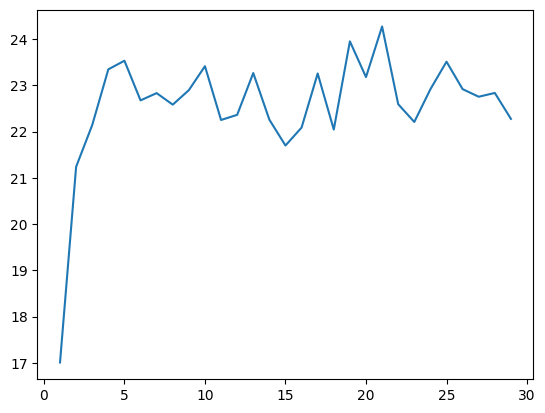

In [ ]:
plt.plot(taus, mfpt)

## Other

In [ ]:
def blind_mfpt(tau, w_long):
    """MFPT of a biexponential blind searcher: d2 = tau, d1 = D1."""
    return run_flight(L, Nt, r, float(tau),
                      dscales=[float(tau), D1],
                      weights=[1.0 - w_long, w_long],
                      W=W, seed=SEED, h=H)


def main(wgrid, out):
    t0 = time.time()
    print("rho=%.4g   mean free path 1/(2 r rho) = %.0f" % (rho, MFP))
    print("w_long grid: %s\n" % wgrid)
    grid, detail = {}, {}
    for tv in TAUS:
        best_T, best_w, best_s = np.inf, None, None
        row = []
        for wl in wgrid:
            m, s, f = blind_mfpt(tv, wl)
            row.append((wl, m, s))
            if m < best_T:
                best_T, best_w, best_s = m, wl, s
        grid[str(tv)] = best_T
        detail[str(tv)] = {"w_long": best_w, "T": best_T, "SEM": best_s,
                           "scan": row}
        spread = max(x[1] for x in row) - min(x[1] for x in row)
        print("tau=%2d  T=%7.1f  SEM=%4.1f  (best w_long=%.2f, "
              "spread over grid=%5.1f = %.1f%%)  [%.0fs]"
              % (tv, best_T, best_s, best_w, spread, 100 * spread / best_T,
                 time.time() - t0))
    json.dump(grid, open(out, 'w'), indent=1)
    json.dump(detail, open(out.replace('.json', '_detail.json'), 'w'), indent=1)
    print("\nwrote %s (and _detail.json)" % out)
    T = np.array([grid[str(t)] for t in TAUS])
    print("T/MFP ranges %.2f to %.2f  -> pinned at the ceiling, flat in tau"
          % (T.min() / MFP, T.max() / MFP))
    return grid

In [ ]:
"""
Regenerates blind_grid.json: the MFPT of the OPTIMISED blind biexponential
searcher as a function of the start distance tau. These are the blind values
used in the visual-vs-blind phase map (Table 3 / crossover_map*.png).

This script replaces a pair of throwaway shell one-liners that originally
produced blind_grid.json and were never saved. Defaults reproduce those runs
bit for bit (same seed, same walker count, same substep, same w_long grid).

WHAT IS OPTIMISED
-----------------
The step length distribution is biexponential (Eq. (4) of the writeup),
    p(l) = sum_i (omega_i / d_i) exp(-l/d_i),
with a short "intensive" mode d2 = tau (search the neighbourhood of the target
being sought) and a long "relocating" mode d1 = D1 = 1000. At each tau we scan
the weight of the long mode, w_long, and keep the BEST (lowest MFPT).

CAVEAT ON THE DEFAULT GRID
--------------------------
The original runs scanned only w_long in {0.1, 1.0} -- two points. That is a
very coarse optimisation. It is defensible only because the optimisation is
marginal in 2D (see Sec. 4 of the writeup: the two candidates come out within
a few percent of each other, and both sit at the mean free path ceiling), but
it is not a real optimisation. Use --fine for a 7 point scan if you want to
check that nothing is missed between them.

IMPORTANT: this differs deliberately from run_levernier_blind.py, which holds
the policy FIXED (pure ballistic) across tau. That is the right choice there,
because re-optimising at each tau would confound the tau dependence of the
Levernier prefactor with a tau dependent change of strategy. Here we DO want
the optimised strategy, because the phase map asks which strategy wins.

Requires sim_flight.py in the same directory. Runtime ~2 min (default).
"""


# ---------------- environment (must match the visual runs) ----------------
L, Nt, r = 300, 90, 0.5
rho = Nt / L**2                      # 1e-3
MFP = 1 / (2 * r * rho)              # mean free path ceiling = 1000

# ---------------- run parameters (reproduce the originals) ----------------
TAUS = [2, 4, 6, 8, 10, 12, 16, 20, 25, 30]
D1 = 1000.0                          # long relocating scale
W = 1800                             # walkers per (tau, w_long)
H = 0.4                              # integration substep (converged, see writeup)
SEED = 7
WGRID_COARSE = [0.1, 1.0]                              # what the originals used
WGRID_FINE = [0.0, 0.02, 0.05, 0.1, 0.3, 0.6, 1.0]     # optional sanity scan

OUT = '/home/claude/blind_grid.json'


def blind_mfpt(tau, w_long):
    """MFPT of a biexponential blind searcher: d2 = tau, d1 = D1."""
    return run_flight(L, Nt, r, float(tau),
                      dscales=[float(tau), D1],
                      weights=[1.0 - w_long, w_long],
                      W=W, seed=SEED, h=H)


def main(wgrid, out):
    t0 = time.time()
    print("rho=%.4g   mean free path 1/(2 r rho) = %.0f" % (rho, MFP))
    print("w_long grid: %s\n" % wgrid)
    grid, detail = {}, {}
    for tv in TAUS:
        best_T, best_w, best_s = np.inf, None, None
        row = []
        for wl in wgrid:
            m, s, f = blind_mfpt(tv, wl)
            row.append((wl, m, s))
            if m < best_T:
                best_T, best_w, best_s = m, wl, s
        grid[str(tv)] = best_T
        detail[str(tv)] = {"w_long": best_w, "T": best_T, "SEM": best_s,
                           "scan": row}
        spread = max(x[1] for x in row) - min(x[1] for x in row)
        print("tau=%2d  T=%7.1f  SEM=%4.1f  (best w_long=%.2f, "
              "spread over grid=%5.1f = %.1f%%)  [%.0fs]"
              % (tv, best_T, best_s, best_w, spread, 100 * spread / best_T,
                 time.time() - t0))
    json.dump(grid, open(out, 'w'), indent=1)
    json.dump(detail, open(out.replace('.json', '_detail.json'), 'w'), indent=1)
    print("\nwrote %s (and _detail.json)" % out)
    T = np.array([grid[str(t)] for t in TAUS])
    print("T/MFP ranges %.2f to %.2f  -> pinned at the ceiling, flat in tau"
          % (T.min() / MFP, T.max() / MFP))
    return grid


# if __name__ == "__main__":
#     fine = '--fine' in sys.argv
#     main(WGRID_FINE if fine else WGRID_COARSE,
#          OUT.replace('.json', '_fine.json') if fine else OUT)

## Finding best scales

In [ ]:
import numpy as np, json, os, sys, time
from run_blind_grid import blind_mfpt, TAUS, MFP
 
WGRID = [0.0, 0.02, 0.05, 0.1, 0.2, 0.3, 0.6, 1.0]
FN = '/home/claude/blind_fine_cache.json'
cache = json.load(open(FN)) if os.path.exists(FN) else {}
budget = float(sys.argv[1]) if len(sys.argv) > 1 else 260
t0 = time.time()
 
for tv in TAUS:
    for wl in WGRID:
        k = '%d,%.2f' % (tv, wl)
        if k in cache:
            continue
        if time.time() - t0 > budget:
            json.dump(cache, open(FN, 'w'))
            print('BUDGET: %d/%d cells' % (len(cache), len(TAUS)*len(WGRID)))
            sys.exit(0)
        m, s, f = blind_mfpt(tv, wl)
        cache[k] = m
    json.dump(cache, open(FN, 'w'))
    row = [cache['%d,%.2f' % (tv, w)] for w in WGRID]
    b = int(np.argmin(row))
    print('tau=%2d  best w_long=%.2f  T=%7.1f   [%.0fs]'
          % (tv, WGRID[b], row[b], time.time()-t0), flush=True)
 
json.dump(cache, open(FN, 'w'))
grid = {}
for tv in TAUS:
    row = [cache['%d,%.2f' % (tv, w)] for w in WGRID]
    grid[str(tv)] = min(row)
json.dump(grid, open('/home/claude/blind_grid_fine.json', 'w'), indent=1)
print('COMPLETE -> blind_grid_fine.json')

In [ ]:
"""
Levernier prefactor test for the blind ballistic-flight searcher in 2D.

Tests Eq. (3) of Levernier et al. (arXiv:2002.00278), which for a non-compact
walk in a confining volume V reads

    T ~ A V^((dw+psi)/d) / a^psi * [ 1 - B (a/lc)^psi ]

Transcribed to this problem (a -> r, lc -> tau, V -> 1/rho):

    T(tau) = T_inf * [ 1 - B (r/tau)^psi ],     T_inf = 1/(2 r rho)

with psi = d - dw. The searcher's long mode d1 is comparable to the mean free
path, so it typically finds a target within ~one flight and never reaches the
diffusive regime => ballistic branch dw = 1 => psi = d - 1 = 1 in 2D.

The point of the test: T is NOT independent of tau. It SATURATES. The residual
tau-dependence is a re-encounter bonus (start near a live target, cheaply
re-find it) that decays as (r/tau)^psi and is spent by tau ~ a few r.

Requires: sim_flight.py (run_flight) in the same directory.
Runtime: ~2 min.
"""
import numpy as np, json, time
from sim_flight import run_flight

# ---------------- environment ----------------
L, Nt, r = 300, 90, 0.5
rho = Nt / L**2                 # 1e-3
T_inf_theory = 1 / (2 * r * rho)  # mean free path = 1000
b = 1 / np.sqrt(np.pi * rho)      # cell radius = 17.8

# ---------------- walk config ----------------
# NOTE: we hold the POLICY FIXED across tau (pure long mode = ballistic).
# This is the clean way to test the Levernier prefactor: re-optimising
# {omega_i} at each tau would mix the prefactor's tau-dependence with a
# tau-dependent change of strategy, and the two are different effects.
D1 = 1000.0
WEIGHTS = [0.0, 1.0]            # pure long mode
TAUS = np.linspace(0.2, 20, 40)
W = 5000                        # walkers per point
H = 0.4                         # integration substep


def scan(seed=21):
    out = []
    t0 = time.time()
    for tv in TAUS:
        m, s, f = run_flight(L, Nt, r, float(tv), [float(tv), D1], WEIGHTS,
                             W=W, seed=seed, h=H)
        out.append((tv, m, s))
        print("tau=%5.1f  T=%7.1f  SEM=%4.1f  cens=%.3f  [%.0fs]"
              % (tv, m, s, f, time.time() - t0), flush=True)
    return np.array(out)


def fit(data, psi):
    """Fit T = T_inf [1 - B (r/tau)^psi]; linear in x=(r/tau)^psi."""
    tau, T = data[:, 0], data[:, 1]
    x = (r / tau) ** psi
    slope, intercept = np.polyfit(x, T, 1)
    T_inf = intercept
    B = -slope / intercept
    pred = T_inf * (1 - B * x)
    ss = np.sum((T - pred) ** 2)
    st = np.sum((T - T.mean()) ** 2)
    return T_inf, B, 1 - ss / st, pred


print("rho=%.4g  mean free path 1/(2 r rho)=%.0f  cell radius b=%.1f\n"
        % (rho, T_inf_theory, b))
data = scan()
np.save("blind_levernier_scan.npy", data)

print("\n--- fit  T = T_inf [1 - B (r/tau)^psi] ---")
for psi in (1, 2):
    T_inf, B, R2, pred = fit(data, psi)
    tag = "<-- ballistic branch dw=1" if psi == 1 else "   (diffusive dw=2)"
    print(" psi=%d:  T_inf=%6.0f   B=%.2f   R2=%.3f   %s"
            % (psi, T_inf, B, R2, tag))

T_inf, B, R2, pred = fit(data, 1)
print("\n T_inf/theory = %.3f  (should be ~1)" % (T_inf / T_inf_theory))
print("\n tau      sim     fit(psi=1)")
for (tv, m, s), p in zip(data, pred):
    print("  %5.1f  %7.1f  %7.1f" % (tv, m, p))

json.dump({"taus": data[:, 0].tolist(), "T": data[:, 1].tolist(),
            "SEM": data[:, 2].tolist(), "T_inf": T_inf, "B": B, "R2": R2,
            "T_inf_theory": T_inf_theory},
            open("blind_levernier_fit.json", "w"), indent=1)
print("\nsaved blind_levernier_fit.json")

rho=0.001  mean free path 1/(2 r rho)=1000  cell radius b=17.8

tau=  0.2  T=  419.0  SEM=12.0  cens=0.000  [4s]
tau=  0.7  T=  761.0  SEM=14.2  cens=0.000  [9s]
tau=  1.2  T=  871.9  SEM=14.7  cens=0.000  [14s]
tau=  1.7  T=  929.9  SEM=14.9  cens=0.000  [20s]
tau=  2.2  T=  972.8  SEM=15.0  cens=0.000  [26s]
tau=  2.7  T=  966.1  SEM=14.9  cens=0.000  [32s]
tau=  3.2  T=  972.2  SEM=14.8  cens=0.000  [38s]
tau=  3.8  T=  998.7  SEM=14.9  cens=0.000  [45s]
tau=  4.3  T= 1003.5  SEM=14.8  cens=0.000  [51s]
tau=  4.8  T= 1022.0  SEM=15.0  cens=0.000  [57s]
tau=  5.3  T= 1013.0  SEM=14.7  cens=0.000  [63s]
tau=  5.8  T= 1000.8  SEM=14.4  cens=0.000  [69s]
tau=  6.3  T= 1009.2  SEM=14.7  cens=0.000  [75s]
tau=  6.8  T=  984.7  SEM=14.4  cens=0.000  [81s]
tau=  7.3  T=  994.8  SEM=14.9  cens=0.000  [87s]
tau=  7.8  T= 1018.7  SEM=15.1  cens=0.000  [94s]
tau=  8.3  T= 1007.8  SEM=14.7  cens=0.000  [100s]
tau=  8.8  T= 1011.1  SEM=15.0  cens=0.000  [106s]
tau=  9.3  T= 1003.1  SEM=14.4  cens

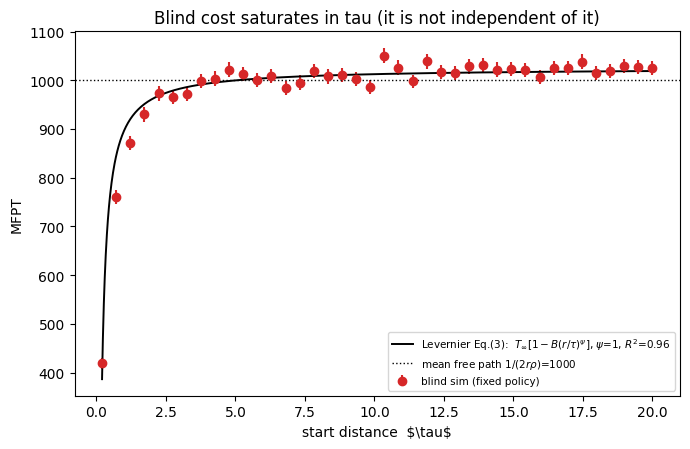

In [ ]:
import numpy as np, json

import matplotlib.pyplot as plt
d=json.load(open('blind_levernier_fit.json'))
tau=np.array(d['taus']); T=np.array(d['T']); S=np.array(d['SEM'])
Tinf,B=d['T_inf'],d['B']; r=0.5; rho=1e-3
tt=np.logspace(np.log10(tau[0]),np.log10(tau[-1]),200)

plt.figure(figsize=(7,4.6))
plt.errorbar(tau,T,yerr=S,fmt='o',color='C3',label='blind sim (fixed policy)')

plt.semilogx(tt,Tinf*(1-B*(r/tt)),'k-',lw=1.4,
             label=r'Levernier Eq.(3):  $T_\infty[1-B(r/\tau)^\psi]$, $\psi$=1, $R^2$=%.2f'%d['R2'])

plt.axhline(1/(2*r*rho),color='k',ls=':',lw=1,label=r'mean free path $1/(2r\rho)$=1000')
A=2/(np.pi*rho); pc=np.arcsin(r/3.)/np.pi; VReff=max(3*pc**0.36,r)



plt.xscale('linear')

plt.xlabel(r'start distance  \$\tau\$'); plt.ylabel('MFPT')
plt.title('Blind cost saturates in tau (it is not independent of it)')
plt.legend(fontsize=7.5); plt.tight_layout(); plt.show()

# Crossover

In [ ]:
import numpy as np, json, os, time, sys
from sim2 import mfpt
L, Nt, r = 50, 100, 0.5
taus = [2, 4, 6, 8, 10, 12, 16, 20, 25, 30]
VRs = [1, 2, 3, 5, 8, 12]
W = 1000
FN = 'visual_cache_v2.json'
cache = json.load(open(FN)) if os.path.exists(FN) else {}
t0 = time.time()
budget = 260
for tv in taus:
    for vr in VRs:
        k = '%d,%d' % (tv, vr)
        if k in cache:
            continue
        if time.time() - t0 > budget:
            print('BUDGET; %d/%d done' % (len(cache), len(taus)*len(VRs))); json.dump(cache, open(FN,'w')); sys.exit(0)
        m, s, f = mfpt(L=L, Nt=Nt, r=r, VR=float(vr), tau=float(tv),
                       theta=2*np.pi, W=W, seed=300+tv*7+vr, rule='dir')
        cache[k] = m
        print('tau=%2d VR=%2d T=%7.1f [%.0fs]' % (tv, vr, m, time.time()-t0), flush=True)
    json.dump(cache, open(FN, 'w'))
json.dump(cache, open(FN, 'w'))
print('GRID COMPLETE %d cells [%.0fs]' % (len(cache), time.time()-t0))

tau= 6 VR= 1 T=   49.3 [0s]
tau= 6 VR= 2 T=   30.5 [0s]
tau= 6 VR= 3 T=   21.3 [0s]
tau= 6 VR= 5 T=   10.8 [1s]
tau= 6 VR= 8 T=    7.3 [1s]
tau= 6 VR=12 T=    6.9 [1s]
tau= 8 VR= 1 T=   45.5 [1s]
tau= 8 VR= 2 T=   34.4 [1s]
tau= 8 VR= 3 T=   22.9 [1s]
tau= 8 VR= 5 T=   11.1 [1s]
tau= 8 VR= 8 T=    7.4 [1s]
tau= 8 VR=12 T=    7.3 [2s]
tau=10 VR= 1 T=   50.8 [2s]
tau=10 VR= 2 T=   38.3 [2s]
tau=10 VR= 3 T=   23.2 [2s]
tau=10 VR= 5 T=   10.0 [2s]
tau=10 VR= 8 T=    7.7 [2s]
tau=10 VR=12 T=    7.3 [2s]
tau=12 VR= 1 T=   50.6 [2s]
tau=12 VR= 2 T=   41.4 [3s]
tau=12 VR= 3 T=   20.5 [3s]
tau=12 VR= 5 T=   10.6 [3s]
tau=12 VR= 8 T=    7.4 [3s]
tau=12 VR=12 T=    7.5 [3s]
tau=16 VR= 1 T=   48.2 [3s]
tau=16 VR= 2 T=   36.1 [3s]
tau=16 VR= 3 T=   24.3 [4s]
tau=16 VR= 5 T=   10.9 [4s]
tau=16 VR= 8 T=    7.3 [4s]
tau=16 VR=12 T=    8.4 [4s]
tau=20 VR= 1 T=   50.9 [4s]
tau=20 VR= 2 T=   38.5 [4s]
tau=20 VR= 3 T=   26.8 [4s]
tau=20 VR= 5 T=   12.5 [4s]
tau=20 VR= 8 T=    8.2 [5s]
tau=20 VR=12 T=    7

In [ ]:
import numpy as np, json
import matplotlib; import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
c2=json.load(open('visual_cache_v2.json'));
blind=json.load(open('blind_grid.json'))
taus=[2,4,6,8,10,12,16,20,25,30]; VRs=[1,2,3,5,8,12]
V2=np.array([[c2['%d,%d'%(t,v)] for v in VRs] for t in taus])

Tb=np.array([blind[str(t)] for t in taus])
Z2=(Tb[:,None]<V2).astype(int); 


fig,ax=plt.subplots(1,2,figsize=(13.5,5))
for a,Z,ttl in [(ax[1],Z2,'AFTER fix (exact segment contact)')]:
    a.imshow(Z.T,origin='lower',cmap=ListedColormap(['red','blue']),vmin=0,vmax=1,aspect='auto',
             extent=[-0.5,len(taus)-0.5,-0.5,len(VRs)-0.5])
    a.set_xticks(range(len(taus))); a.set_xticklabels(taus)
    a.set_yticks(range(len(VRs))); a.set_yticklabels(VRs)
    a.set_xlabel('tau'); a.set_ylabel('VR'); a.set_title(ttl+'\n(red=visual wins, blue=blind wins)',fontsize=9)
plt.tight_layout(); plt.savefig('crossover_map_v2.png',dpi=130)
print()
print('VR* per tau (min VR where visual wins), AFTER fix:')
for i,t in enumerate(taus):
    w=[VRs[j] for j in range(len(VRs)) if Z2[i,j]==0]
    print('  tau=%2d  VR*>=%s'%(t,min(w) if w else 'none'))


NameError: name 'blind' is not defined